<a href="https://colab.research.google.com/github/saam-b/ChelkoudIbtissam-ML-AutoML-Homework/blob/AutoML_Homework.ipynb/ML_AutoML_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning & AutoML Homework
Chelkoud Ibtissam

---

## Projet 1 – Segmentation clientèle

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

### Chargement du dataset

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Exploration des données

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Analyse visuelle

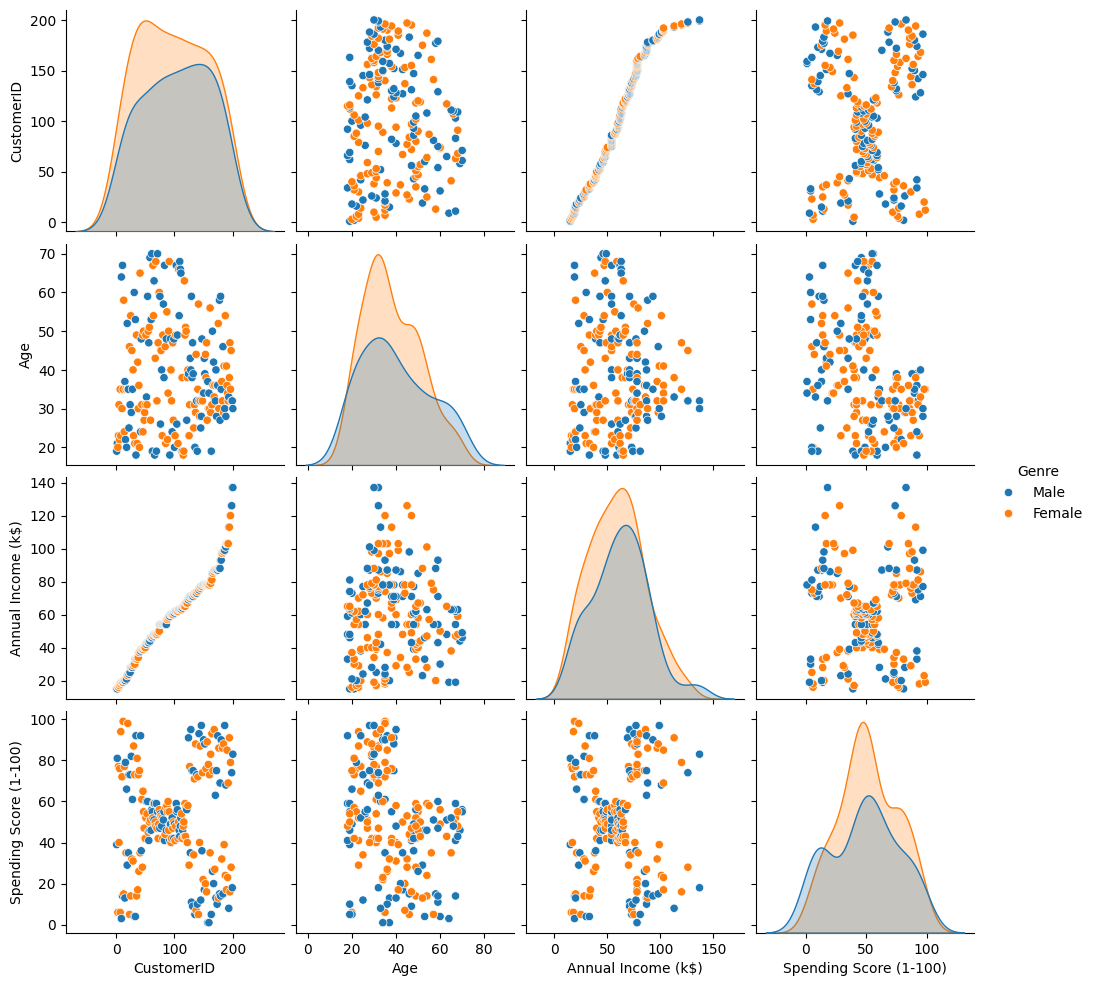

In [ ]:
sns.pairplot(df, hue="Genre")
plt.show()

### Clustering avec K-Means

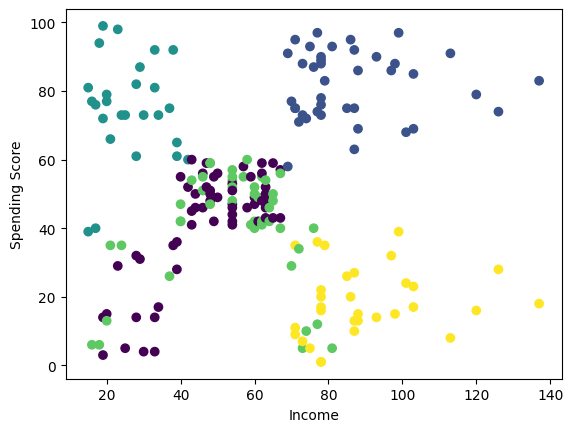

In [ ]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_KMeans'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

### Clustering Agglomératif

In [ ]:
agg = AgglomerativeClustering(n_clusters=5)
df['Cluster_Agg'] = agg.fit_predict(X_scaled)

### Interprétation
Décrire chaque segment et proposer une stratégie marketing.

---
## Projet 2 – Détection de fraude

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df_fraud = pd.read_csv("creditcard.csv")
df_fraud['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
X = df_fraud.drop('Class', axis=1)
y = df_fraud['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[56851,    13],
       [   30,    68]])

---
## Mini état de l’art sur AutoML
AutoML automatise le choix des modèles et des hyperparamètres.

### TPOT
Utilise des algorithmes génétiques.

### Auto-sklearn
Utilise l’optimisation bayésienne.

---
## Application AutoML sur Projet 2

In [ ]:
!pip install tpot

In [ ]:
from tpot import TPOTClassifier

tpot = TPOTClassifier(generations=5, population_size=20, random_state=42)
tpot.fit(X_train, y_train)

y_pred_auto = tpot.predict(X_test)
print(classification_report(y_test, y_pred_auto))

tpot.fitted_pipeline_

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:33699
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:32783'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44059 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44059
INFO:distributed.core:Starting established connection to tcp://127.0.0.1

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.09      0.86      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.92      0.58     56962
weighted avg       1.00      0.98      0.99     56962



Pipeline(steps=[('standardscaler', StandardScaler()),
                ('passthrough', Passthrough()),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('binarizer',
                                                                                 Binarizer(threshold=0.0126479301056))])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('gaussiannb', GaussianNB())])

In [ ]:
from sklearn.metrics import classification_report

y_pred_auto = tpot.predict(X_test)
print(classification_report(y_test, y_pred_auto))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.09      0.86      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.92      0.58     56962
weighted avg       1.00      0.98      0.99     56962



Le modèle AutoML (TPOT) a amélioré le recall pour la classe fraude,
ce qui est crucial pour la détection des transactions frauduleuses.


In [ ]:
tpot.fitted_pipeline_


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('passthrough', Passthrough()),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('binarizer',
                                                                                 Binarizer(threshold=0.0126479301056))])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('gaussiannb', GaussianNB())])